In [ ]:
# Importing required libraries
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        


In [110]:
# Load the dataset
df = pd.read_csv(r"C:\Users\BIT\Desktop\AIML ASSIGNMENT\data\raw_daily_water_consumption.csv")

# Display first 5 rows
df.head()

,Date,Person_ID,Age,Gender,City,Temperature_C,Activity_Level,Water_Consumed_Liters,Consumption_scaled
0,2025-03-20,P0053,27.0,Female,Karachi,24.8,High,2.85,0.540070
1,2025-03-30,P0015,58.0,Male,Rawalpindi,NaN,Medium,2.28,0.341463
2,2025-11-10,P0006,21.0,Female,Islamabad,23.4,Low,2.03,0.254355
3,2025-11-14,P0059,39.0,Male,Lahore,NaN,Medium,NaN,0.787456
4,2025-08-16,P0050,42.0,Male,Rawalpindi,NaN,Low,2.78,0.515679


In [ ]:
#Basic information of the data

# Shape of dataset (rows, columns)
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:", df.columns)

# Data types and non-null values
df.info()

# Statistical summary
df.describe()

Shape of dataset: (38325, 9)

Columns: Index(['Date', 'Person_ID', 'Age', 'Gender', 'City', 'Temperature_C',
       'Activity_Level', 'Water_Consumed_Liters', 'Consumption_scaled'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 38325 entries, 0 to 38324
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   36400 non-null  str    
 1   Person_ID              36409 non-null  str    
 2   Age                    36434 non-null  float64
 3   Gender                 36386 non-null  str    
 4   City                   36375 non-null  str    
 5   Temperature_C          36404 non-null  float64
 6   Activity_Level         36398 non-null  str    
 7   Water_Consumed_Liters  36456 non-null  float64
 8   Consumption_scaled     36471 non-null  float64
dtypes: float64(4), str(5)
memory usage: 2.6 MB


,Age,Temperature_C,Water_Consumed_Liters,Consumption_scaled
count,36434.000000,36404.000000,36456.000000,36471.000000
mean,40.461355,28.541075,2.722212,0.496041
std,13.361615,7.797427,0.550770,0.191936
min,18.000000,15.000000,1.300000,0.000000
25%,30.000000,21.800000,2.340000,0.365854
50%,41.000000,28.600000,2.720000,0.494774
75%,52.000000,35.300000,3.130000,0.637631
max,64.000000,42.000000,4.170000,1.000000


In [ ]:
# Checking for missing values in each column
missing_values = df.isnull().sum()

print("Missing Values:\n", missing_values)

Missing Values:
 Date                     1925
Person_ID                1916
Age                      1891
Gender                   1939
City                     1950
Temperature_C            1921
Activity_Level           1927
Water_Consumed_Liters    1869
Consumption_scaled       1854
dtype: int64


In [ ]:
# Dropping critical columns with missing values
df = df.dropna(subset=['Date', 'Person_ID'])

# Filling numerical columns
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Temperature_C'] = df['Temperature_C'].fillna(df['Temperature_C'].mean())
df['Water_Consumed_Liters'] = df['Water_Consumed_Liters'].fillna(df['Water_Consumed_Liters'].mean())


# Filling categorical columns
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Activity_Level'] = df['Activity_Level'].fillna(df['Activity_Level'].mode()[0])

In [146]:
#Comparing before and after of handling
print("\nMissing values AFTER handling:\n")
print(df.isnull().sum())

print("\nTotal missing values AFTER:", df.isnull().sum().sum())


Missing values AFTER handling:

Date                     0
Person_ID                0
Age                      0
Gender                   0
City                     0
Temperature_C            0
Activity_Level           0
Water_Consumed_Liters    0
Consumption_scaled       0
dtype: int64

Total missing values AFTER: 0


In [147]:
# Converting 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sorting dataset by date (important for time series)
df = df.sort_values(by='Date')

# Reseting index
df.reset_index(drop=True, inplace=True)

df.head()

,Date,Person_ID,Age,Gender,City,Temperature_C,Activity_Level,Water_Consumed_Liters,Consumption_scaled
0,2025-01-01,P0053,27.0,Female,Karachi,40.5,High,3.76,0.857143
1,2025-01-01,P0001,21.0,Female,Karachi,22.1,Medium,2.40,0.383275
2,2025-01-01,P0099,60.0,Female,Faisalabad,38.0,Medium,3.21,0.665505
3,2025-01-01,P0046,36.0,Male,Faisalabad,16.9,Low,1.63,0.114983
4,2025-01-01,P0021,18.0,Male,Multan,35.8,Medium,3.20,0.662021


In [148]:
# Checking for duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Removing duplicates if any
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Number of duplicate rows: 0
Duplicates after removal: 0


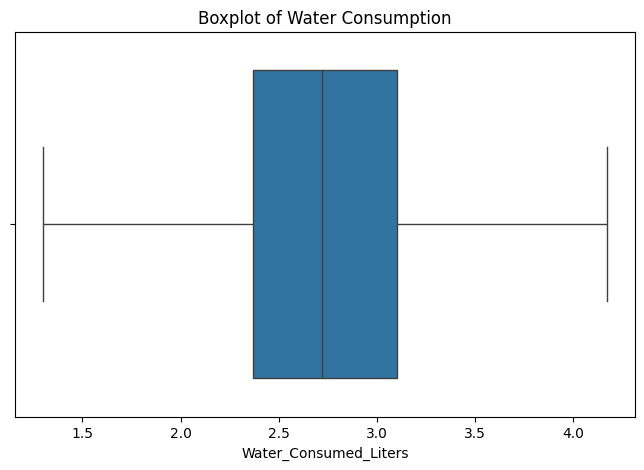

In [149]:
# Visualizing outliers using boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Water_Consumed_Liters'])
plt.title("Boxplot of Water Consumption")
plt.show()

In [150]:
# Normalizing consumption (Min-Max Scaling)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Consumption_scaled'] = scaler.fit_transform(df[['Water_Consumed_Liters']])

df.head()

,Date,Person_ID,Age,Gender,City,Temperature_C,Activity_Level,Water_Consumed_Liters,Consumption_scaled
0,2025-01-01,P0053,27.0,Female,Karachi,40.5,High,3.76,0.857143
1,2025-01-01,P0001,21.0,Female,Karachi,22.1,Medium,2.40,0.383275
2,2025-01-01,P0099,60.0,Female,Faisalabad,38.0,Medium,3.21,0.665505
3,2025-01-01,P0046,36.0,Male,Faisalabad,16.9,Low,1.63,0.114983
4,2025-01-01,P0021,18.0,Male,Multan,35.8,Medium,3.20,0.662021


In [ ]:
# Saving cleaned dataset for next notebook

df.to_csv(r"C:\Users\BIT\Desktop\AIML ASSIGNMENT\data\raw_daily_water_consumption.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
